In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import torch, numpy as np
from pathlib import Path
from config import config

In [3]:
from run_models import run_VAE, run_KMeans
from utils.common import extract_latents

d:\MSc\3. Spring 2026\CSE715\Project\vae-audio-clustering\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [5]:
root = Path("../..")

### check that config.MODEL_TYPE = "basic"

In [6]:
config.MODEL_TYPE

'basic'

In [ ]:
basic_vae, latent_dim, train_loader, test_loader, vae_history, study = run_VAE(model_type="basic", plot_dir_name="easy_1_basic_vae", root=root) #type: ignore

In [9]:
study.best_params

{'HIDDEN_DIM_1': 2048,
 'HIDDEN_DIM_2': 256,
 'LATENT_DIM': 16,
 'LR': 0.0003521358805467869,
 'BATCH_SIZE': 32}

In [10]:
train_latents, _ = extract_latents(model=basic_vae, loader=train_loader, device=device)
test_latents,  _  = extract_latents(model=basic_vae, loader=test_loader,  device=device)

In [11]:
vae_latents = np.concatenate([train_latents, test_latents], axis=0)

In [12]:
vae_kmeans, vae_metrics = run_KMeans(vae_latents, model_type="easy_1_basic_vae", root=root)




Optimal k        : 6
Inertia (WCSS)   : 1486.4181
Silhouette Score : 0.3342
CH Index         : 1983.3734
DB Index         : 1.0122





<Figure size 800x550 with 0 Axes>

In [13]:
from visualizations import plot_tsne_clustering_comparison
from sklearn.metrics import silhouette_score

In [14]:
TSNE_DIR = root / config.TSNE_DIR

In [15]:
TSNE_DIR.mkdir(exist_ok=True, parents=True)

Computing t-SNE embeddings (this may take a minute)...
Saved → ..\..\results\clustering\tsne\easy_1_basic_vae.png


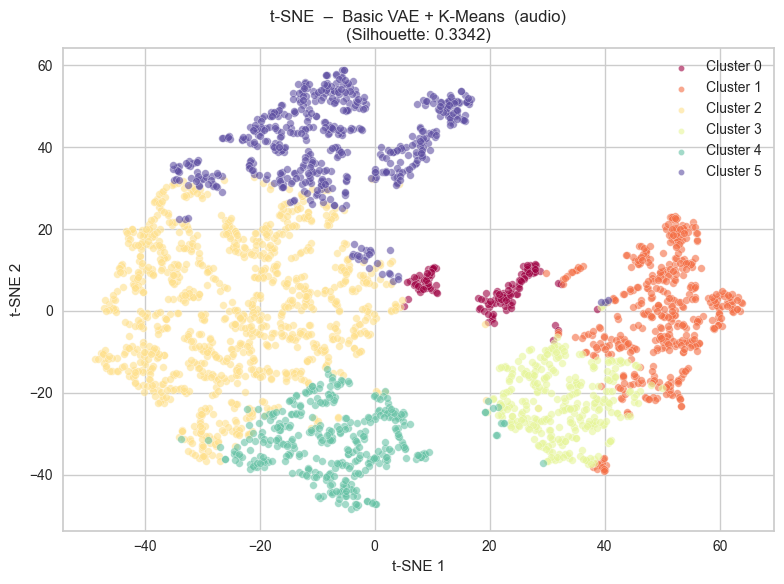

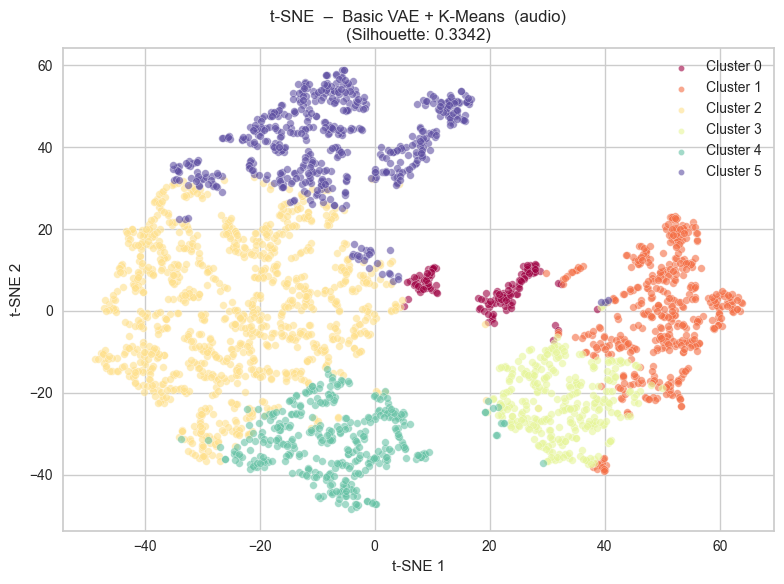

In [16]:
plot_tsne_clustering_comparison(
    vae_latents,
    [vae_kmeans.labels_, ],
    ["Basic VAE + K-Means  (audio)", ],
    scores=[silhouette_score(vae_latents, vae_kmeans.labels_),],
    save_path= TSNE_DIR / "easy_1_basic_vae.png"
)